<div style="background:#300A6E; background:linear-gradient(120deg,#0B00CF,#300A6E); padding:26px; border-radius:12px; border-bottom:4px solid #FF2D2B; text-align:center;">
<h1 style="color:#FFFFFF; font-size:24px; margin:0; text-align:center;">CUSTOMER SEGMENTATION WITH RFM ANALYSIS</h1>
<p style="color:#FFFFFF; font-size:17px; margin:12px 0 0; text-align:center;">Understanding Customer Behavior and Planning Targeted Campaigns</p>
</div>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We load the dataset and create a copy for analysis, keeping the
original DataFrame unchanged during preprocessing.
</p>


In [1]:
import numpy as np  # Numerical operations
import pandas as pd  # Data loading and manipulation
import seaborn as sns  # Statistical data visualization
import matplotlib.pyplot as plt  # Chart creation and customization
import datetime as dt  # Date and time operations

In [2]:
# Load the dataset and create a working copy
df_ = pd.read_csv("/kaggle/input/flo-data/flo_data_20k.csv")
df = df_.copy()

<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
First 10 Observations
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We inspect the first 10 rows to get an initial overview of the
dataset’s columns and values.
</p>

In [3]:
df.head(10)


,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,799.38,[KADIN]
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.0,2.0,159.97,1853.58,"[ERKEK, COCUK, KADIN, AKTIFSPOR]"
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]"
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]"
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,159.99,[AKTIFSPOR]
5,e585280e-aae1-11e9-a2fc-000d3a38a36f,Desktop,Offline,2018-11-18,2021-03-13,2018-11-18,2021-03-13,1.0,2.0,150.87,49.99,[KADIN]
6,c445e4ee-6242-11ea-9d1a-000d3a38a36f,Android App,Android App,2020-03-04,2020-10-18,2020-10-18,2020-03-04,3.0,1.0,59.99,315.94,[AKTIFSPOR]
7,3f1b4dc8-8a7d-11ea-8ec0-000d3a38a36f,Mobile,Offline,2020-05-15,2020-08-12,2020-05-15,2020-08-12,1.0,1.0,49.99,113.64,[COCUK]
8,cfbda69e-5b4f-11ea-aca7-000d3a38a36f,Android App,Android App,2020-01-23,2021-03-07,2021-03-07,2020-01-25,3.0,2.0,120.48,934.21,"[ERKEK, COCUK, KADIN]"
9,1143f032-440d-11ea-8b43-000d3a38a36f,Mobile,Mobile,2019-07-30,2020-10-04,2020-10-04,2019-07-30,1.0,1.0,69.98,95.98,"[KADIN, AKTIFSPOR]"


<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
Variable Names
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We list the column names to identify the variables available for analysis.
</p>

In [4]:
df.columns


Index(['master_id', 'order_channel', 'last_order_channel', 'first_order_date',
       'last_order_date', 'last_order_date_online', 'last_order_date_offline',
       'order_num_total_ever_online', 'order_num_total_ever_offline',
       'customer_value_total_ever_offline', 'customer_value_total_ever_online',
       'interested_in_categories_12'],
      dtype='object')

<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
Descriptive Statistics
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We summarize the numerical variables using counts, means,
standard deviations, minimums, quartiles, and maximums.
</p>

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
order_num_total_ever_online,19945.0,3.110855,4.225647,1.00,1.00,2.00,4.00,200.00
order_num_total_ever_offline,19945.0,1.913913,2.062880,1.00,1.00,1.00,2.00,109.00
customer_value_total_ever_offline,19945.0,253.922597,301.532853,10.00,99.99,179.98,319.97,18119.14
customer_value_total_ever_online,19945.0,497.321690,832.601886,12.99,149.98,286.46,578.44,45220.13


<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
Missing Value Analysis
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We check each column for missing values.
</p>

In [6]:
df.isnull().any()


master_id                            False
order_channel                        False
last_order_channel                   False
first_order_date                     False
last_order_date                      False
last_order_date_online               False
last_order_date_offline              False
order_num_total_ever_online          False
order_num_total_ever_offline         False
customer_value_total_ever_offline    False
customer_value_total_ever_online     False
interested_in_categories_12          False
dtype: bool

<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
Variable Types
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We inspect column data types to identify numeric variables
and columns that may require conversion, such as dates stored as text.
</p>

In [7]:
df.dtypes

master_id                             object
order_channel                         object
last_order_channel                    object
first_order_date                      object
last_order_date                       object
last_order_date_online                object
last_order_date_offline               object
order_num_total_ever_online          float64
order_num_total_ever_offline         float64
customer_value_total_ever_offline    float64
customer_value_total_ever_online     float64
interested_in_categories_12           object
dtype: object

<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
Dataset Dimensions
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We check the number of rows and columns in the dataset.
</p>

In [8]:
df.shape

(19945, 12)

<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
Total Orders and Total Spending
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We combine each customer’s online and offline order counts
to calculate total orders. Similarly, we add online and offline
spending amounts to calculate total spending.
These variables will be used as the Frequency and Monetary
metrics in the RFM analysis.
</p>



In [9]:
# Calculate each customer's total number of orders
df["total_order_number"] = df["order_num_total_ever_online"] + df["order_num_total_ever_offline"]


In [10]:
# Calculate each customer's total spending
df["total_price"] =  df["customer_value_total_ever_online"]  +  df["customer_value_total_ever_offline"]

<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
Results Check
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We inspect the summary statistics of the newly calculated
total orders and total spending variables.
</p>

In [11]:
df[["total_order_number","total_price" ]].describe()

,total_order_number,total_price
count,19945.000000,19945.000000
mean,5.024768,751.244287
std,4.742707,895.402173
min,2.000000,44.980000
25%,3.000000,339.980000
50%,4.000000,545.270000
75%,6.000000,897.780000
max,202.000000,45905.100000


<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
Data Types Before Date Conversion
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We review the column data types before converting the date columns
from text to datetime.
</p>

In [12]:
df.dtypes

master_id                             object
order_channel                         object
last_order_channel                    object
first_order_date                      object
last_order_date                       object
last_order_date_online                object
last_order_date_offline               object
order_num_total_ever_online          float64
order_num_total_ever_offline         float64
customer_value_total_ever_offline    float64
customer_value_total_ever_online     float64
interested_in_categories_12           object
total_order_number                   float64
total_price                          float64
dtype: object

<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
Date Variable Conversion
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We convert the date columns from text to datetime so that we can
compare dates and calculate the number of days since each customer’s
last purchase.
</p>

In [13]:
# List the date columns to convert
date_list = ["first_order_date","last_order_date", "last_order_date_online","last_order_date_offline" ]    

In [14]:
# Convert each date column to datetime
for date in date_list:
   df[date] = pd.to_datetime(df[date])

In [15]:
df.dtypes

master_id                                    object
order_channel                                object
last_order_channel                           object
first_order_date                     datetime64[ns]
last_order_date                      datetime64[ns]
last_order_date_online               datetime64[ns]
last_order_date_offline              datetime64[ns]
order_num_total_ever_online                 float64
order_num_total_ever_offline                float64
customer_value_total_ever_offline           float64
customer_value_total_ever_online            float64
interested_in_categories_12                  object
total_order_number                          float64
total_price                                 float64
dtype: object

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We group customers by their recorded order channel and summarize
the number of unique customers, total orders, and total spending.
Order and spending totals include both online and offline purchases
for the customers in each group.
</p>

In [16]:
# Summarize customer counts, total orders, and total spending by order channel
df.groupby("order_channel").agg({"master_id": lambda x : x.nunique(), "total_order_number": lambda x : x.sum(), "total_price": lambda x : x.sum()})

,master_id,total_order_number,total_price
order_channel,,,
Android App,9495,52269.0,7819062.76
Desktop,2735,10920.0,1610321.46
Ios App,2833,15351.0,2525999.93
Mobile,4882,21679.0,3028183.16


<h3 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
Customer Counts, Orders, and Spending by Order Channel
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
The following bar charts compare customer groups by their recorded
order channel, showing unique customer counts, total orders, and
total spending. Order and spending totals include both online and
offline purchases made by the customers in each group.
</p>

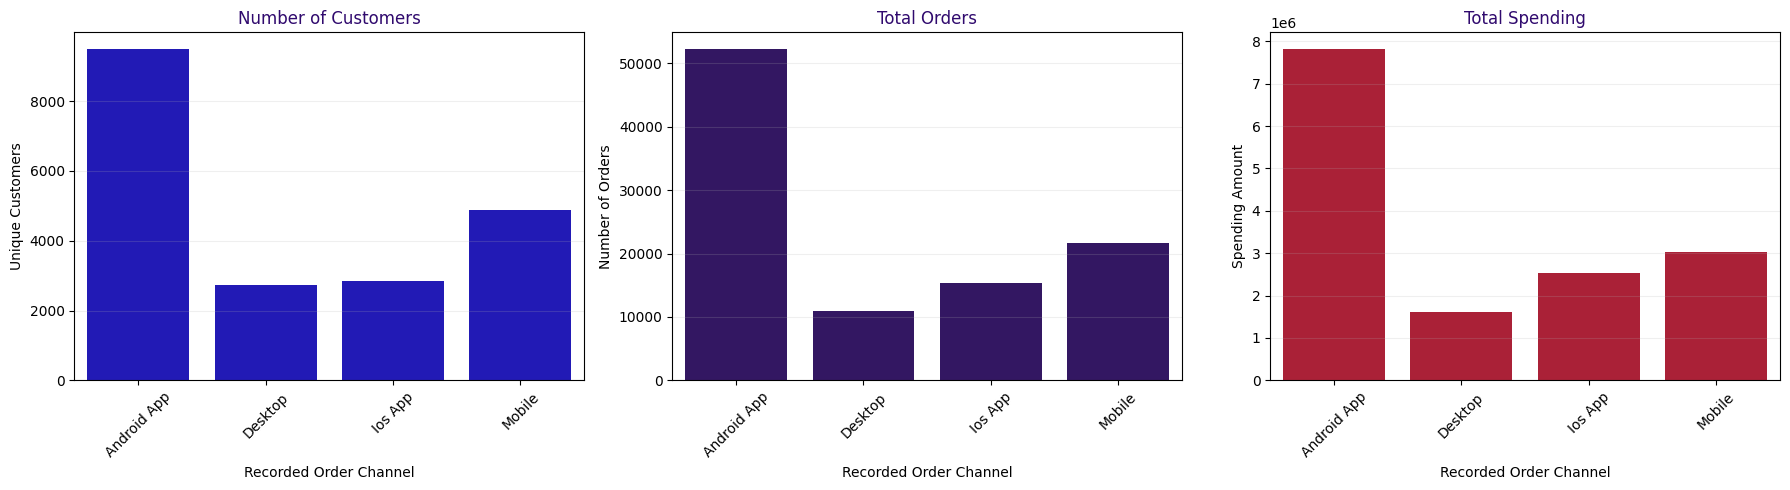

In [17]:
# Group the data by recorded order channel
channel_stats = df.groupby("order_channel").agg({
    "master_id": lambda x: x.nunique(),
    "total_order_number": lambda x: x.sum(),
    "total_price": lambda x: x.sum()
}).reset_index()

# Create three side-by-side charts
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Number of unique customers
sns.barplot(
    data=channel_stats,
    x="order_channel",
    y="master_id",
    ax=ax[0],
    color="#0B00CF"
)
ax[0].set_title("Number of Customers", color="#300A6E")
ax[0].set_ylabel("Unique Customers")

# Total orders
sns.barplot(
    data=channel_stats,
    x="order_channel",
    y="total_order_number",
    ax=ax[1],
    color="#300A6E"
)
ax[1].set_title("Total Orders", color="#300A6E")
ax[1].set_ylabel("Number of Orders")

# Total spending
sns.barplot(
    data=channel_stats,
    x="order_channel",
    y="total_price",
    ax=ax[2],
    color="#C10A28"
)
ax[2].set_title("Total Spending", color="#300A6E")
ax[2].set_ylabel("Spending Amount")

# Format each chart
for chart in ax:
    chart.set_xlabel("Recorded Order Channel")
    chart.tick_params(axis="x", labelrotation=45)
    chart.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We list the 10 customers with the highest total spending
across online and offline purchases.
</p>

In [18]:
df.sort_values(by = "total_price" , ascending = False).head(10)

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,total_order_number,total_price
11150,5d1c466a-9cfd-11e9-9897-000d3a38a36f,Android App,Desktop,2013-10-11,2021-04-30,2021-04-30,2020-12-24,200.0,2.0,684.97,45220.13,"[AKTIFCOCUK, ERKEK, COCUK, KADIN, AKTIFSPOR]",202.0,45905.10
4315,d5ef8058-a5c6-11e9-a2fc-000d3a38a36f,Android App,Android App,2018-08-06,2021-02-23,2021-02-23,2020-07-06,67.0,1.0,130.49,36687.80,"[AKTIFCOCUK, ERKEK, KADIN, AKTIFSPOR]",68.0,36818.29
7613,73fd19aa-9e37-11e9-9897-000d3a38a36f,Ios App,Offline,2014-01-14,2021-05-18,2021-01-30,2021-05-18,81.0,1.0,1263.76,32654.34,"[ERKEK, COCUK, KADIN, AKTIFSPOR]",82.0,33918.10
13880,7137a5c0-7aad-11ea-8f20-000d3a38a36f,Ios App,Offline,2021-03-01,2021-04-13,2021-03-18,2021-04-13,10.0,1.0,538.94,30688.47,"[ERKEK, KADIN, AKTIFSPOR]",11.0,31227.41
9055,47a642fe-975b-11eb-8c2a-000d3a38a36f,Android App,Offline,2021-04-07,2021-04-27,2021-04-07,2021-04-27,1.0,3.0,18119.14,2587.20,[AKTIFSPOR],4.0,20706.34
7330,a4d534a2-5b1b-11eb-8dbd-000d3a38a36f,Desktop,Desktop,2020-02-16,2021-04-30,2021-04-30,2020-12-18,66.0,4.0,843.68,17599.89,"[ERKEK, KADIN, AKTIFSPOR]",70.0,18443.57
8068,d696c654-2633-11ea-8e1c-000d3a38a36f,Ios App,Ios App,2017-05-10,2021-04-13,2021-04-13,2019-08-15,69.0,1.0,82.48,16836.09,"[AKTIFCOCUK, ERKEK, COCUK, KADIN, AKTIFSPOR]",70.0,16918.57
163,fef57ffa-aae6-11e9-a2fc-000d3a38a36f,Mobile,Desktop,2016-11-08,2021-05-12,2021-05-12,2020-07-09,36.0,1.0,180.73,12545.37,"[ERKEK, AKTIFSPOR]",37.0,12726.10
7223,cba59206-9dd1-11e9-9897-000d3a38a36f,Android App,Android App,2013-02-21,2021-05-09,2021-05-09,2020-01-25,130.0,1.0,49.99,12232.25,"[AKTIFCOCUK, ERKEK, KADIN, AKTIFSPOR]",131.0,12282.24
18767,fc0ce7a4-9d87-11e9-9897-000d3a38a36f,Desktop,Desktop,2018-11-24,2020-11-11,2020-11-11,2019-12-06,18.0,2.0,64.97,12038.18,"[ERKEK, KADIN]",20.0,12103.15


<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We list the 10 customers with the highest total number of orders
across online and offline purchases.
</p>

In [19]:
df.sort_values(by = "total_order_number", ascending = False).head(10)

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,total_order_number,total_price
11150,5d1c466a-9cfd-11e9-9897-000d3a38a36f,Android App,Desktop,2013-10-11,2021-04-30,2021-04-30,2020-12-24,200.0,2.0,684.97,45220.13,"[AKTIFCOCUK, ERKEK, COCUK, KADIN, AKTIFSPOR]",202.0,45905.10
7223,cba59206-9dd1-11e9-9897-000d3a38a36f,Android App,Android App,2013-02-21,2021-05-09,2021-05-09,2020-01-25,130.0,1.0,49.99,12232.25,"[AKTIFCOCUK, ERKEK, KADIN, AKTIFSPOR]",131.0,12282.24
8783,a57f4302-b1a8-11e9-89fa-000d3a38a36f,Android App,Offline,2019-08-07,2020-11-04,2020-09-07,2020-11-04,2.0,109.0,10239.46,143.98,"[AKTIFCOCUK, ERKEK, COCUK, KADIN, AKTIFSPOR]",111.0,10383.44
2619,fdbe8304-a7ab-11e9-a2fc-000d3a38a36f,Android App,Offline,2018-10-18,2020-06-30,2018-10-18,2020-06-30,1.0,87.0,8432.25,139.98,[ERKEK],88.0,8572.23
6322,329968c6-a0e2-11e9-a2fc-000d3a38a36f,Ios App,Ios App,2019-02-14,2021-04-05,2021-04-05,2020-02-17,2.0,81.0,3997.55,242.81,[ERKEK],83.0,4240.36
7613,73fd19aa-9e37-11e9-9897-000d3a38a36f,Ios App,Offline,2014-01-14,2021-05-18,2021-01-30,2021-05-18,81.0,1.0,1263.76,32654.34,"[ERKEK, COCUK, KADIN, AKTIFSPOR]",82.0,33918.10
9347,44d032ee-a0d4-11e9-a2fc-000d3a38a36f,Mobile,Mobile,2019-02-11,2021-02-11,2021-02-11,2020-12-24,3.0,74.0,4640.77,543.28,"[KADIN, AKTIFSPOR]",77.0,5184.05
10954,b27e241a-a901-11e9-a2fc-000d3a38a36f,Mobile,Mobile,2015-09-12,2021-04-01,2021-04-01,2019-10-08,72.0,3.0,292.93,5004.95,"[AKTIFCOCUK, ERKEK, KADIN, AKTIFSPOR]",75.0,5297.88
8068,d696c654-2633-11ea-8e1c-000d3a38a36f,Ios App,Ios App,2017-05-10,2021-04-13,2021-04-13,2019-08-15,69.0,1.0,82.48,16836.09,"[AKTIFCOCUK, ERKEK, COCUK, KADIN, AKTIFSPOR]",70.0,16918.57
7330,a4d534a2-5b1b-11eb-8dbd-000d3a38a36f,Desktop,Desktop,2020-02-16,2021-04-30,2021-04-30,2020-12-18,66.0,4.0,843.68,17599.89,"[ERKEK, KADIN, AKTIFSPOR]",70.0,18443.57


<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
The following function calculates total orders and total spending,
converts date columns to datetime, and displays channel-level summaries,
top customers, and column data types. It returns the processed
DataFrame for use in the next steps of the analysis.
</p>

In [20]:
def preprocess(dataframe):
    dataframe["total_order_number"] = dataframe["order_num_total_ever_online"] + dataframe["order_num_total_ever_offline"]
    dataframe["total_price"] =  dataframe["customer_value_total_ever_online"]  +  dataframe["customer_value_total_ever_offline"]

    for x in dataframe.columns:
      if "date" in x:
          dataframe[x] = pd.to_datetime(dataframe[x])

    dataframe.groupby("order_channel").agg({"master_id": lambda x : x.nunique(), 
                                     "total_order_number": lambda x : x.sum(),
                                     "total_price": lambda x : x.sum()})
   
    print(dataframe.sort_values(by = "total_price" , ascending = False).head(10))
    print(dataframe.sort_values(by = "total_order_number", ascending = False).head(10))
    
    print(dataframe.head())
    print(dataframe.dtypes)

    return dataframe

    

<h2 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
2. Calculation of RFM Metrics
</h2>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We calculate three metrics to summarize each customer's shopping behavior:
</p>

<ul style="color:#300A6E; font-size:16px; line-height:1.8;">
<li><b>Recency:</b> Days since the customer's last purchase, measured as of the analysis date.</li>
<li><b>Frequency:</b> Total number of online and offline orders.</li>
<li><b>Monetary:</b> Total spending across online and offline purchases.</li>
</ul>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We use June 1, 2021 as the fixed analysis date for this historical dataset.
</p>

In [21]:
df["last_order_date"].max()

Timestamp('2021-05-30 00:00:00')

In [22]:
import datetime as dt
today_date = dt.datetime(2021,6,1, 0, 0, 0)

In [23]:
rfm = df.groupby("master_id").agg({"last_order_date": lambda date : (today_date - date.max()).days,
                            "total_order_number": lambda x : x.sum(),
                            "total_price": lambda x: x.sum()})

In [24]:
rfm.columns = ["recency", "frequency", "monetary"]

In [25]:
rfm.head()

,recency,frequency,monetary
master_id,,,
00016786-2f5a-11ea-bb80-000d3a38a36f,10,5.0,776.07
00034aaa-a838-11e9-a2fc-000d3a38a36f,298,3.0,269.47
000be838-85df-11ea-a90b-000d3a38a36f,213,4.0,722.69
000c1fe2-a8b7-11ea-8479-000d3a38a36f,27,7.0,874.16
000f5e3e-9dde-11ea-80cd-000d3a38a36f,20,7.0,1620.33


<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We visualize the distributions of Recency, Frequency, and Monetary
metrics to understand customer shopping patterns before assigning RFM scores.
</p>

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


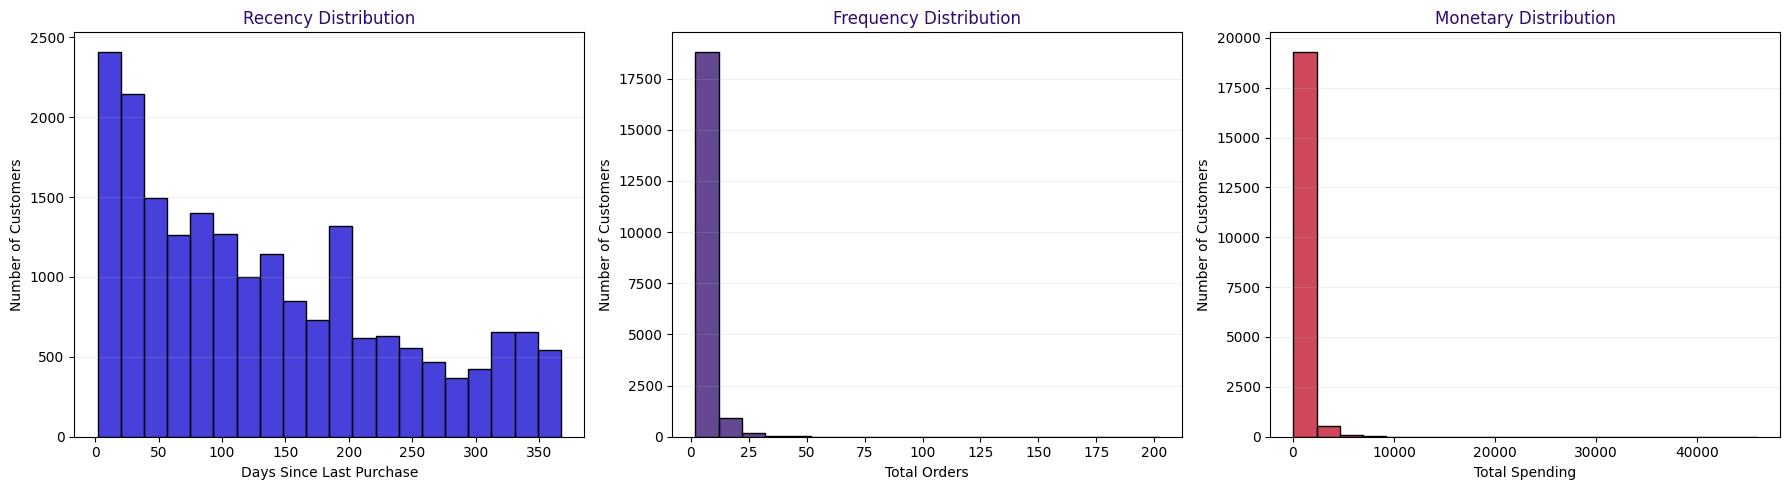

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["recency"], bins=20, color="#0B00CF", ax=ax[0])
ax[0].set_title("Recency Distribution", color="#300A6E")
ax[0].set_xlabel("Days Since Last Purchase")

sns.histplot(rfm["frequency"], bins=20, color="#300A6E", ax=ax[1])
ax[1].set_title("Frequency Distribution", color="#300A6E")
ax[1].set_xlabel("Total Orders")

sns.histplot(rfm["monetary"], bins=20, color="#C10A28", ax=ax[2])
ax[2].set_title("Monetary Distribution", color="#300A6E")
ax[2].set_xlabel("Total Spending")

for chart in ax:
    chart.set_ylabel("Number of Customers")
    chart.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


<h2 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
3. Calculation of RFM Scores
</h2>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
We assign scores from 1 to 5 to the Recency, Frequency, and Monetary
metrics using quantile-based groups. Higher Frequency and Monetary
values receive higher scores. For Recency, fewer days since the last
purchase receive higher scores.
</p>

In [27]:
rfm["recency_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])
rfm["frequency_score"] = pd.qcut(rfm["frequency"].rank(method="first"),5, labels=[1,2,3,4,5])
rfm["monetary_score"] = pd.qcut(rfm["monetary"],5, labels = [1,2,3,4,5])

                                                          

In [28]:
rfm["RF_SCORE"] = rfm["recency_score"].astype(str) + rfm["frequency_score"].astype(str)

<h2 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
4. Customer Segmentation
</h2>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
Customers are assigned to segments using their combined Recency and
Frequency scores. Monetary values are not used to assign segment labels
in this notebook, but they are reviewed later to describe the spending
profiles of the segments.
</p>

In [29]:
data = {
    'Segment': ['Champions', 'Loyal Customers',"Potential Loyalists","New Customers","Promising","Need Attention","About To Sleep", 'At Risk',"Can't Lose Them",'Hibernating Customers', 'Recent Customers'],
    'Description': [
        "Recent, frequent, and high-spending customers.",
        "Customers who shop consistently and have strong long-term value.",
        "Recent customers with the potential to become loyal.",
        "Customers who made a recent first or early purchase.",
        "Recent customers with low purchase frequency.",
        "Customers whose activity requires attention to prevent disengagement.",
        "Customers whose recency and frequency scores are declining.",
        "Previously valuable customers who have not purchased recently.",
        "Previously high-value customers who are at serious risk of churn.",
        "Customers with low recency and low purchase frequency.", 
        "Customers who have recently shopped but have not yet become loyal"
    ]
}


df_segments= pd.DataFrame(data)



In [30]:
styled_segments = df_segments.style.set_properties(
    subset=["Description"],
    **{
        "text-align": "center",
        "white-space": "normal",
        "min-width": "500px",
        "max-width": "500px"
    }
).set_properties(
    subset=["Segment"],
    **{
        "text-align": "center",
        "min-width": "220px"
    }
).set_table_styles([
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#C7CEE8"),
            ("color", "white"),
            ("font-size", "16px")
        ]
    }
])

styled_segments

,Segment,Description
0,Champions,"Recent, frequent, and high-spending customers."
1,Loyal Customers,Customers who shop consistently and have strong long-term value.
2,Potential Loyalists,Recent customers with the potential to become loyal.
3,New Customers,Customers who made a recent first or early purchase.
4,Promising,Recent customers with low purchase frequency.
5,Need Attention,Customers whose activity requires attention to prevent disengagement.
6,About To Sleep,Customers whose recency and frequency scores are declining.
7,At Risk,Previously valuable customers who have not purchased recently.
8,Can't Lose Them,Previously high-value customers who are at serious risk of churn.
9,Hibernating Customers,Customers with low recency and low purchase frequency.


In [31]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'}

In [32]:
rfm["segment"] = rfm["RF_SCORE"].replace(seg_map, regex=True)

In [33]:
rfm["segment"].value_counts()

segment
hibernating            3589
loyal_customers        3375
at_risk                3152
potential_loyalists    2925
champions              1920
about_to_sleep         1643
cant_loose             1194
need_attention          806
new_customers           673
promising               668
Name: count, dtype: int64

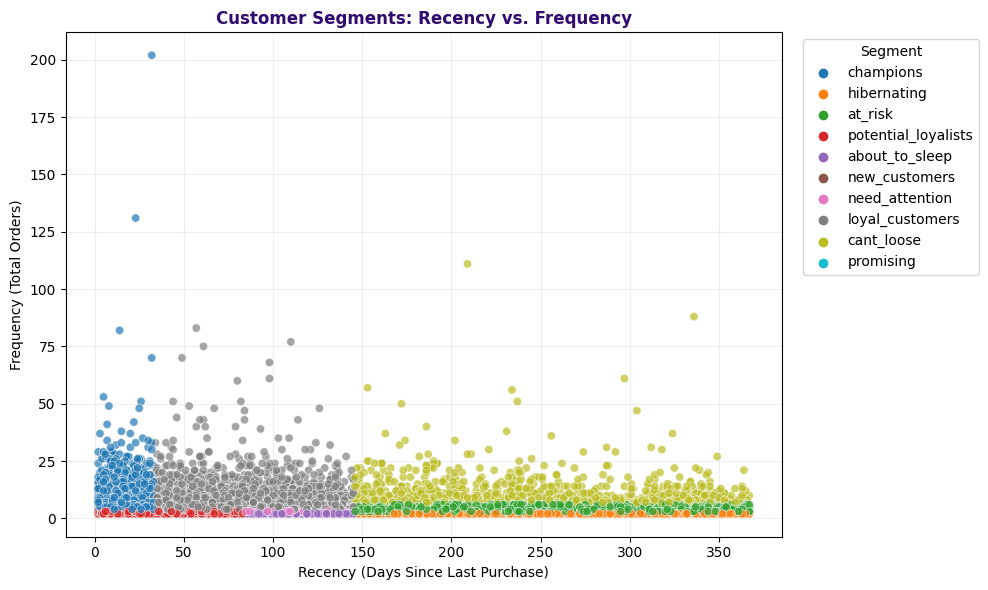

In [34]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="recency",
    y="frequency",
    hue="segment",
    palette="tab10",
    alpha=0.7
)

plt.title("Customer Segments: Recency vs. Frequency", color="#300A6E", fontweight="bold")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Frequency (Total Orders)")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
The following chart shows how customers are distributed across the RFM segments.
It helps identify the largest customer groups and supports prioritizing
segment-specific marketing actions.
</p>

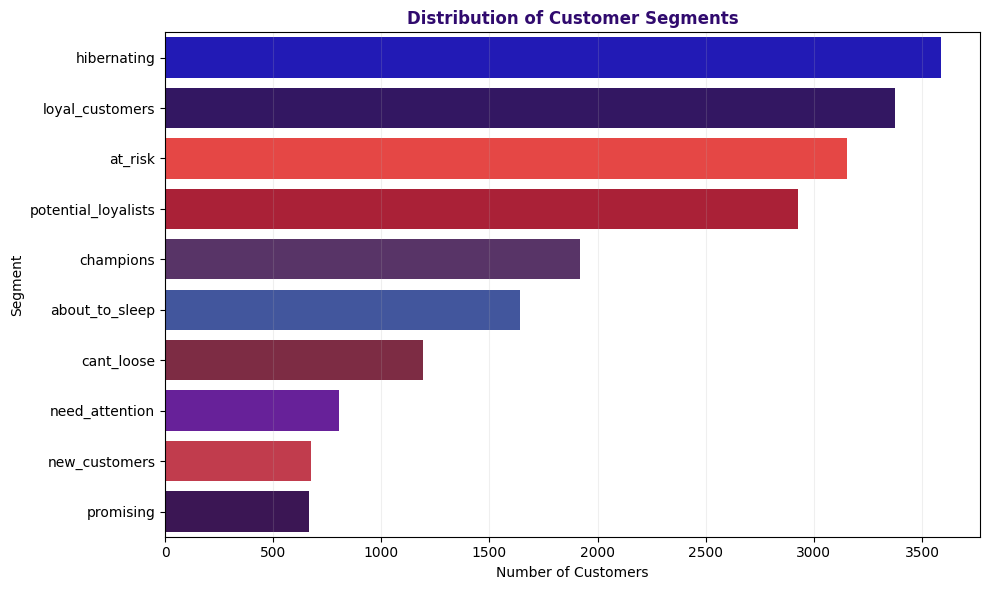

In [35]:
segment_order = rfm["segment"].value_counts().index

segment_colors = [
    "#0B00CF", "#300A6E", "#FF2D2B", "#C10A28",
    "#5B2C6F", "#334EAC", "#8B1E3F", "#6A0DAD",
    "#D7263D", "#3D0C5E"
]

plt.figure(figsize=(10, 6))

sns.countplot(
    data=rfm,
    y="segment",
    order=segment_order,
    palette=segment_colors
)

plt.title("Distribution of Customer Segments", color="#300A6E", fontweight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

<h2 style="color:#300A6E; border-bottom:2px solid #C10A28; padding-bottom:8px;">
5. Marketing Strategies and Action Plan
</h2>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
RFM segments are translated into targeted marketing actions in this section.
The aim is to retain high-value customers, reactivate customers at risk of churn,
and encourage promising or new customers to make repeat purchases.
</p>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
Before defining campaign actions, we examine the average Recency, Frequency,
and Monetary values for each customer segment. This comparison helps us
understand the behavioral and spending profiles behind the segment labels.
</p>

In [36]:
rfm.groupby("segment").agg({"recency": lambda x : x.mean(),
                           "frequency": lambda x : x.mean(),
                           "monetary": lambda x : x.mean()})

,recency,frequency,monetary
segment,,,
about_to_sleep,114.031649,2.406573,361.649373
at_risk,242.328997,4.470178,648.325038
cant_loose,235.159129,10.716918,1481.652446
champions,17.142187,8.965104,1410.708938
hibernating,247.426303,2.391474,362.583299
loyal_customers,82.557926,8.356444,1216.257224
need_attention,113.037221,3.739454,553.436638
new_customers,17.976226,2.000000,344.049495
potential_loyalists,36.869744,3.310769,533.741344


<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
Using the RFM segments, we identify customers who match the profiles defined
for two marketing cases. The selected customer IDs are then exported as CSV
files so they can be used in campaign planning.
</p>

<h3 style="color:#300A6E;">
Case A — New Women's Footwear Brand
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
FLO is introducing a new women’s footwear brand. To support the launch,
the campaign targets customers who are both highly valuable and interested
in the women’s category. Customers in the <b>champions</b> and
<b>loyal_customers</b> segments who have purchased from the
<b>KADIN</b> category will be selected. Their customer IDs will be exported
to a CSV file for campaign outreach.
</p>

In [37]:
target_segment = rfm[(rfm["segment"]=="champions") | (rfm["segment"]== "loyal_customers")]
target_segment = target_segment.reset_index()
target_segment_id = target_segment["master_id"]



In [38]:
case_a_customers = df[(df["interested_in_categories_12"].str.contains("KADIN", na=False)) & (df["master_id"].isin(target_segment_id)) ][["master_id"]]
case_a_customers.head()

,master_id
0,cc294636-19f0-11eb-8d74-000d3a38a36f
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f
8,cfbda69e-5b4f-11ea-aca7-000d3a38a36f
11,c2e15af2-9eed-11e9-9897-000d3a38a36f
33,fb840306-1219-11ea-a001-000d3a38a36f


In [39]:
case_a_customers.to_csv(
    "case_a_womens_footwear_customers.csv",
    index=False
)

<h3 style="color:#300A6E;">
Case B — Men's and Children's Product Discount
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
FLO is planning a discount of up to 40% on men’s and children’s products.
The campaign targets customers who have previously shown interest in these
categories and belong to segments with reactivation potential:
<b>about_to_sleep</b>, <b>cant_loose</b>, <b>hibernating</b>, and
<b>new_customers</b>. Their customer IDs will be exported for targeted
campaign outreach.
</p>

In [40]:
target_2 = rfm[(rfm["segment"]== "about_to_sleep") | (rfm["segment"]== "cant_loose") | (rfm["segment"] == "hibernating") | ((rfm["segment"]== "new_customers"))]
target_2 = target_2.reset_index()
target_2_id = target_2["master_id"]
target_2_man_child = df[
    (
        df["interested_in_categories_12"].str.contains("ERKEK", na=False)
        | df["interested_in_categories_12"].str.contains("COCUK", na=False)
    )
    & (df["master_id"].isin(target_2_id))
][["master_id"]]



In [41]:
target_2_man_child.to_csv(
    "case_b_men_children_discount_customers.csv",
    index=False
)

<h3 style="color:#300A6E; border-bottom:1px solid #FF2D2B; padding-bottom:6px;">
Recommended Marketing Actions
</h3>

<p style="color:#300A6E; font-size:16px; line-height:1.8; text-align:justify;">
The RFM segmentation enables FLO to create more relevant campaigns for each
customer group. The following actions are illustrative recommendations based
on segment behavior; their business impact should be validated through
campaign measurement or A/B testing.
</p>

<div style="background:#F5F3FF; border-left:5px solid #0B00CF; padding:14px 18px; margin:14px 0; border-radius:6px;">
<b style="color:#300A6E;">Loyal Customers — Champions &amp; Loyal Customers</b>
<ul style="color:#300A6E; line-height:1.7; margin-bottom:0;">
<li>Offer early access to new collections, VIP benefits, or loyalty rewards.</li>
<li>Use personalized product recommendations to maintain engagement.</li>
</ul>
</div>

<div style="background:#FFF1F2; border-left:5px solid #C10A28; padding:14px 18px; margin:14px 0; border-radius:6px;">
<b style="color:#C10A28;">Reactivation — At Risk, Can't Lose, Hibernating</b>
<ul style="color:#300A6E; line-height:1.7; margin-bottom:0;">
<li>Use time-limited discounts, reminders, and personalized email campaigns.</li>
<li>Prioritize customers with historically high spending.</li>
</ul>
</div>

<div style="background:#F3F0FF; border-left:5px solid #FF2D2B; padding:14px 18px; margin:14px 0; border-radius:6px;">
<b style="color:#300A6E;">New Customers — New Customers &amp; Promising</b>
<ul style="color:#300A6E; line-height:1.7; margin-bottom:0;">
<li>Offer a second-purchase incentive after the first order.</li>
<li>Introduce relevant categories to encourage repeat purchasing.</li>
</ul>
</div>